# ftir_29 — the provisional Addis EC series: what the corrected calibration actually gives

## tl;dr

**The corrected calibration already yields a usable provisional Addis EC series — and it
is clean.** Rebuilding both locked OCEC-800 models under the site-held-out protocol
(reproduction gate: raw **1.585x − 3.222**, corrected **0.857x − 1.615** on the fixed 190
at MAC 10, matched to the committed ftir_13/ftir_21 record to <1e-4), the corrected
model's predictions over all **239 dated** evaluation filters give median **2.32 µg/m³**
(IQR 1.62–3.12), max **6.43**, with **zero negative predictions and zero days above
8 µg/m³** — a physically sensible series that involves **no MAC anywhere** (predicted
µg/filter ÷ sampled volume). Seasonality survives at lower levels: Dry **1.67** / Belg
**2.39** / Kiremt **3.62** median — the Kiremt ≈ 2.2× Dry ordering of ftir_17's loading
result. Against the deployed SPARTAN numbers on the same filters the change is a **scale,
not a reshuffle**: provisional = **0.45 × deployed + 0.29** (R² 0.85), halving the median
(4.62 → 2.32); the raw-model (MAC-6-branch) series is the upper envelope at median 3.96,
and corrected-vs-raw is likewise pure scale (slope 0.55, R² 0.86). The series' one honest
caveat travels with it: the HIPS-axis offset, put at **c = 1.82 [1.60, 1.97] µg/m³**
(corrected) and **2.06 [1.93, 2.24]** (raw) — ≈16–22 Mm⁻¹, known to ~10% and excluding
zero — computed here from ftir_15's committed site-cluster draws with no refitting, the
first CI stated directly on `c`.

## Context & Methods

Phase 3 established that the locked calibration (lowest-OC/EC 800 + AIRSpec, site-held-out
protocol) cannot close the last ~2 µg/m³ of the Addis intercept — and that this remainder
is an **x-side (HIPS-axis) additive**, not a calibration defect: ftir_25 showed the offset
is invariant to every y-side choice, ftir_26 ruled out a generic HIPS zero, ftir_28 put the
FTIR-side intercept against MA350 BC(880) at 13× smaller than the HIPS-side one, and all
three surviving explanations (loading-dependent HIPS artifact, curve geometry, real non-EC
absorption) implicate the HIPS axis, not the FTIR predictions.

The corollary nobody has drawn yet: **the calibration's EC series itself is plausibly
usable now, provisionally** — its Addis disagreement is with HIPS, not with any EC
reference. This notebook draws it. It rebuilds the two locked OCEC-800 models (raw and
AIRSpec-corrected) under the site-held-out protocol, asserts they reproduce the committed
ftir_13/ftir_21 Addis metrics exactly, and then reads out what the corrected model says
Addis EC *is*: the full dated time series, its seasonal structure, how it compares with
the deployed SPARTAN numbers, and its honest uncertainty — the raw-model envelope (the
unresolved MAC-fork branch) and the bootstrap CI on the HIPS-axis offset `c`, computed
from ftir_15's committed draws with no refitting.

Conventions: fixed 190-filter cohort for crossplot metrics; `dry_feb` seasons
(Dry Oct–Feb / Belg Mar–May / Kiremt Jun–Sep); MAC = 10 wherever HIPS is converted to an
EC-equivalent axis. The provisional series itself involves **no MAC at all** — FTIR EC is
predicted mass per filter divided by sampled volume.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

sys.path.insert(0, str(Path('scripts').resolve()))
sys.path.insert(0, str((Path('..') / 'ftir_hips_chem' / 'scripts').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from phase3_common import PATHS, PHASE2_TABLES, load_addis_evaluation, load_pool_metadata, load_tor_loadings
from calibration_modes import fit_calibration
from pls_transfer import regression_metrics

TABLE_DIR = Path('output/tables/ftir29')
PLOT_DIR = Path('output/plots/ftir29')
for directory in (TABLE_DIR, PLOT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

INK, MUTED, GREY = '#22252A', '#6B6E75', '#8F8C84'
SEASON_COLOUR = {'Dry': '#D97B29', 'Belg': '#3F7A56', 'Kiremt': '#2C6E9E'}
SEASON_FOR_MONTH = {m: 'Dry' for m in (10, 11, 12, 1, 2)}
SEASON_FOR_MONTH.update({m: 'Belg' for m in (3, 4, 5)})
SEASON_FOR_MONTH.update({m: 'Kiremt' for m in (6, 7, 8, 9)})
SEASON_ORDER = ['Dry', 'Belg', 'Kiremt']

## Data

### 1. Addis evaluation set and the OCEC-800 cohort, identical to ftir_21

In [2]:
etad_eval, X_addis_raw, wavenumbers = load_addis_evaluation(season_for_month=SEASON_FOR_MONTH)
wcols = list(etad_eval.attrs['wcols'])
fabs = etad_eval['Fabs'].to_numpy(float)
volume = etad_eval['SampleVolume_m3'].to_numpy(float)
fixed_mask = etad_eval['EC_deployed_ugm3'].notna().to_numpy()
dated = etad_eval['SamplingStartDate'].notna().to_numpy()
print(f'Addis evaluation: {len(etad_eval)} filters, {int(fixed_mask.sum())} fixed-cohort, '
      f'{int(dated.sum())} dated; seasons: '
      f'{etad_eval.loc[dated, "season"].value_counts().reindex(SEASON_ORDER).to_dict()}')

pool_raw = pd.read_csv(PATHS.ftir_dir / 'local_db/spectra_248_251.csv',
                       usecols=['AnalysisId'] + wcols,
                       dtype={c: np.float32 for c in wcols})
pool_raw = pool_raw[~pool_raw['AnalysisId'].duplicated()].set_index('AnalysisId')
pool_raw.index = pool_raw.index.astype(int)

pool = (load_pool_metadata()
        .merge(load_tor_loadings(), on=['Site', 'date'], how='left', validate='many_to_one')
        .query('TOR_EC_loading_ug > 0')
        .drop_duplicates('FilterId'))
pool['AnalysisId'] = pool['AnalysisId'].astype(int)
pool = pool[pool['AnalysisId'].isin(pool_raw.index)].drop_duplicates('AnalysisId')
pool = pool.set_index('AnalysisId')[['Site', 'TOR_EC_loading_ug']]

ocec = pd.read_csv('output/tables/ftir11/lowest_ocec_800_cohort.csv')

corrected_npz = np.load('output/corrected/improve_pool_corrected_df6.npz', allow_pickle=True)
corrected_row = {int(a): i for i, a in enumerate(corrected_npz['analysis_id'].astype(int))}
etad_npz = np.load('output/corrected/etad_corrected_df6.npz', allow_pickle=True)
etad_corr = pd.DataFrame(etad_npz['corrected'].astype(float))
etad_corr['MediaId'] = etad_npz['media_id'].astype(int)
X_addis_corrected = (etad_corr.groupby('MediaId').mean()
                     .loc[etad_eval['MediaId'].astype(int)].to_numpy(float))

ids_raw = np.array([i for i in dict.fromkeys(int(v) for v in ocec['AnalysisId'])
                    if i in pool.index], dtype=int)
ids_corr = np.array([i for i in ids_raw if i in corrected_row], dtype=int)
print(f'OCEC-800 cohort: raw n = {len(ids_raw)}, corrected n = {len(ids_corr)}')

Filter dataset loaded: 44493 measurements
Sites: ['CHTS' 'ETAD' 'INDH' 'USPA']
Date range: 2013-06-28 to 2024-12-08
Addis evaluation: 239 filters, 190 fixed-cohort, 239 dated; seasons: {'Dry': 105, 'Belg': 61, 'Kiremt': 73}


OCEC-800 cohort: raw n = 800, corrected n = 800


### 2. Rebuild both locked models and assert they reproduce the committed record

`site_heldout` mode reproduced the committed ftir_11/ftir_13 calibrations to <1e-6 in
ftir_21; the same gate is enforced here so every downstream number is anchored.

In [3]:
fits = {}
for label, ids, X_pool, X_addis in (
        ('raw (k=6)', ids_raw, pool_raw.loc[ids_raw, wcols].to_numpy(float), X_addis_raw),
        ('AIRSpec df1=6 (k=5)', ids_corr,
         corrected_npz['corrected'][[corrected_row[i] for i in ids_corr]].astype(float),
         X_addis_corrected)):
    y = pool.loc[ids, 'TOR_EC_loading_ug'].to_numpy(float)
    sites = pool.loc[ids, 'Site'].to_numpy()
    fits[label] = fit_calibration('site_heldout', label, X_pool, y, sites, X_addis, volume)
    m = regression_metrics(fabs[fixed_mask] / 10.0, fits[label].addis_ugm3[fixed_mask])
    print(f'{label:22s} k={fits[label].k}  fixed-cohort MAC10: slope {m["slope"]:.6f}  '
          f'intercept {m["intercept"]:.6f}  R2 {m["R2"]:.3f}  '
          f'heldout TOR: slope {fits[label].heldout["slope"]:.3f} R2 {fits[label].heldout["R2"]:.3f}')

m_raw = regression_metrics(fabs[fixed_mask] / 10.0, fits['raw (k=6)'].addis_ugm3[fixed_mask])
m_cor = regression_metrics(fabs[fixed_mask] / 10.0, fits['AIRSpec df1=6 (k=5)'].addis_ugm3[fixed_mask])
assert fits['raw (k=6)'].k == 6 and fits['AIRSpec df1=6 (k=5)'].k == 5
assert abs(m_raw['slope'] - 1.585381) < 1e-4 and abs(m_raw['intercept'] - (-3.221502)) < 1e-4
assert abs(m_cor['slope'] - 0.857004) < 1e-4 and abs(m_cor['intercept'] - (-1.615099)) < 1e-4
print('reproduction gate PASSED: both models match the committed ftir_13/ftir_21 metrics')

raw (k=6)              k=6  fixed-cohort MAC10: slope 1.585381  intercept -3.221502  R2 0.774  heldout TOR: slope 0.875 R2 0.911


AIRSpec df1=6 (k=5)    k=5  fixed-cohort MAC10: slope 0.857004  intercept -1.615099  R2 0.657  heldout TOR: slope 1.011 R2 0.904
reproduction gate PASSED: both models match the committed ftir_13/ftir_21 metrics


## Results

### 3. The provisional series

In [4]:
series = etad_eval.loc[dated, ['MediaId', 'ExternalFilterId', 'SamplingStartDate', 'season',
                               'Fabs', 'EC_deployed_ugm3']].copy()
series['EC_provisional_ugm3'] = fits['AIRSpec df1=6 (k=5)'].addis_ugm3[dated]
series['EC_rawmodel_ugm3'] = fits['raw (k=6)'].addis_ugm3[dated]
series['HIPS_ECeq_MAC10'] = series['Fabs'] / 10.0
series = series.sort_values('SamplingStartDate').reset_index(drop=True)
series.to_csv(TABLE_DIR / 'provisional_ec_series.csv', index=False)

neg_share = float((series['EC_provisional_ugm3'] < 0).mean())
stats = {
    'n dated filters': len(series),
    'median EC (provisional, µg/m³)': series['EC_provisional_ugm3'].median(),
    'IQR': tuple(series['EC_provisional_ugm3'].quantile([.25, .75]).round(2)),
    'max': series['EC_provisional_ugm3'].max(),
    'share of days > 8 µg/m³': float((series['EC_provisional_ugm3'] > 8).mean()),
    'share negative predictions': neg_share,
    'median deployed EC (same filters)': series['EC_deployed_ugm3'].median(),
    'median raw-model EC': series['EC_rawmodel_ugm3'].median(),
}
for k, v in stats.items():
    print(f'{k:38s} {v}')

seasonal = (series.groupby('season')[['EC_provisional_ugm3', 'EC_rawmodel_ugm3',
                                      'EC_deployed_ugm3', 'HIPS_ECeq_MAC10']]
            .median().reindex(SEASON_ORDER).round(2))
seasonal['n'] = series.groupby('season').size().reindex(SEASON_ORDER)
seasonal.to_csv(TABLE_DIR / 'seasonal_summary.csv')
display(seasonal)

n dated filters                        239
median EC (provisional, µg/m³)         2.315271079485124
IQR                                    (1.62, 3.12)
max                                    6.434830929869037
share of days > 8 µg/m³                0.0
share negative predictions             0.0
median deployed EC (same filters)      4.624584433206255
median raw-model EC                    3.955753263697881


,EC_provisional_ugm3,EC_rawmodel_ugm3,EC_deployed_ugm3,HIPS_ECeq_MAC10,n
season,,,,,
Dry,1.67,2.99,3.27,4.32,105
Belg,2.39,4.06,4.76,4.71,61
Kiremt,3.62,6.06,7.16,5.61,73


### 4. Figure 1 — the provisional Addis EC time series

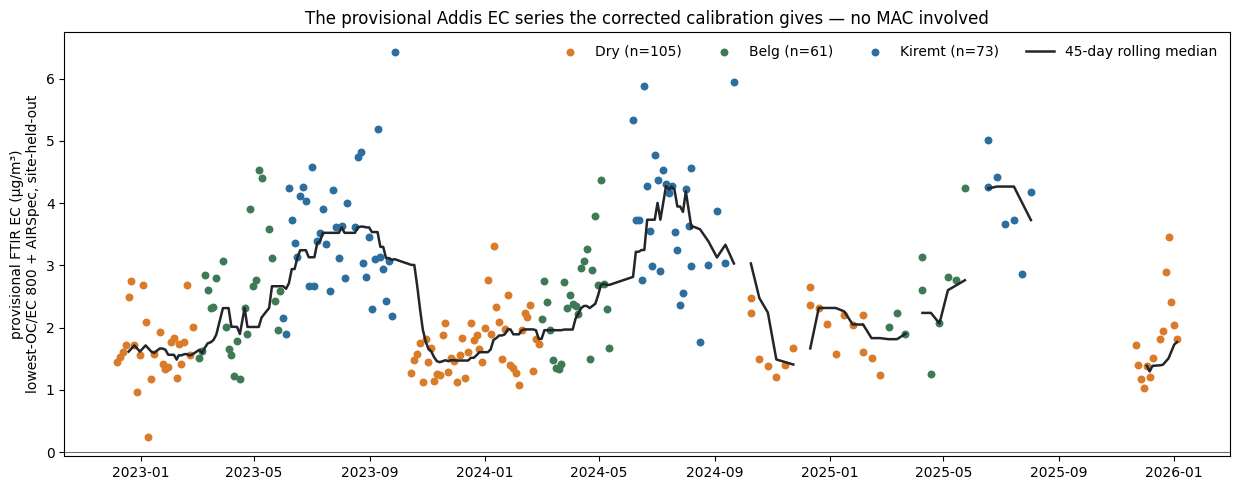

In [5]:
fig, ax = plt.subplots(figsize=(12.5, 5))
for season in SEASON_ORDER:
    part = series[series['season'].eq(season)]
    ax.scatter(part['SamplingStartDate'], part['EC_provisional_ugm3'], s=22,
               color=SEASON_COLOUR[season], label=f'{season} (n={len(part)})', zorder=3)
roll = (series.set_index('SamplingStartDate')['EC_provisional_ugm3']
        .rolling('45D', min_periods=5).median())
ax.plot(roll.index, roll.values, color=INK, lw=1.8, label='45-day rolling median', zorder=4)
ax.axhline(0, color=MUTED, lw=.8)
ax.set_ylabel('provisional FTIR EC (µg/m³)\nlowest-OC/EC 800 + AIRSpec, site-held-out')
ax.set_title('The provisional Addis EC series the corrected calibration gives — no MAC involved')
ax.legend(frameon=False, ncol=4)
fig.tight_layout()
fig.savefig(PLOT_DIR / 'provisional_series.png', dpi=150)
plt.show()

### 5. Figure 2 — what changes versus the deployed SPARTAN numbers

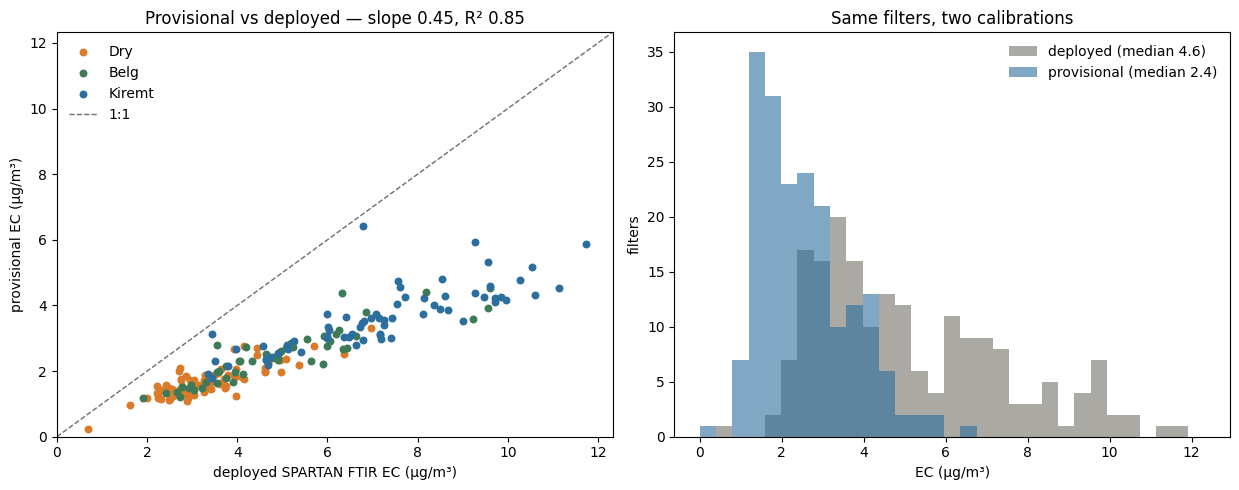

In [6]:
both = series[series['EC_deployed_ugm3'].notna()]
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5))
ax = axes[0]
for season in SEASON_ORDER:
    part = both[both['season'].eq(season)]
    ax.scatter(part['EC_deployed_ugm3'], part['EC_provisional_ugm3'], s=22,
               color=SEASON_COLOUR[season], label=season)
lim = [0, max(both['EC_deployed_ugm3'].max(), both['EC_provisional_ugm3'].max()) * 1.05]
ax.plot(lim, lim, color=MUTED, lw=1, ls='--', label='1:1')
md = regression_metrics(both['EC_deployed_ugm3'].to_numpy(), both['EC_provisional_ugm3'].to_numpy())
ax.set(xlim=lim, ylim=lim, xlabel='deployed SPARTAN FTIR EC (µg/m³)',
       ylabel='provisional EC (µg/m³)',
       title=f'Provisional vs deployed — slope {md["slope"]:.2f}, R² {md["R2"]:.2f}')
ax.legend(frameon=False)
ax = axes[1]
bins = np.linspace(0, lim[1], 32)
ax.hist(both['EC_deployed_ugm3'], bins=bins, color=GREY, alpha=.75,
        label=f'deployed (median {both["EC_deployed_ugm3"].median():.1f})')
ax.hist(both['EC_provisional_ugm3'], bins=bins, color=SEASON_COLOUR['Kiremt'], alpha=.6,
        label=f'provisional (median {both["EC_provisional_ugm3"].median():.1f})')
ax.set(xlabel='EC (µg/m³)', ylabel='filters', title='Same filters, two calibrations')
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(PLOT_DIR / 'provisional_vs_deployed.png', dpi=150)
plt.show()

### 6. Figure 3 — seasonal structure

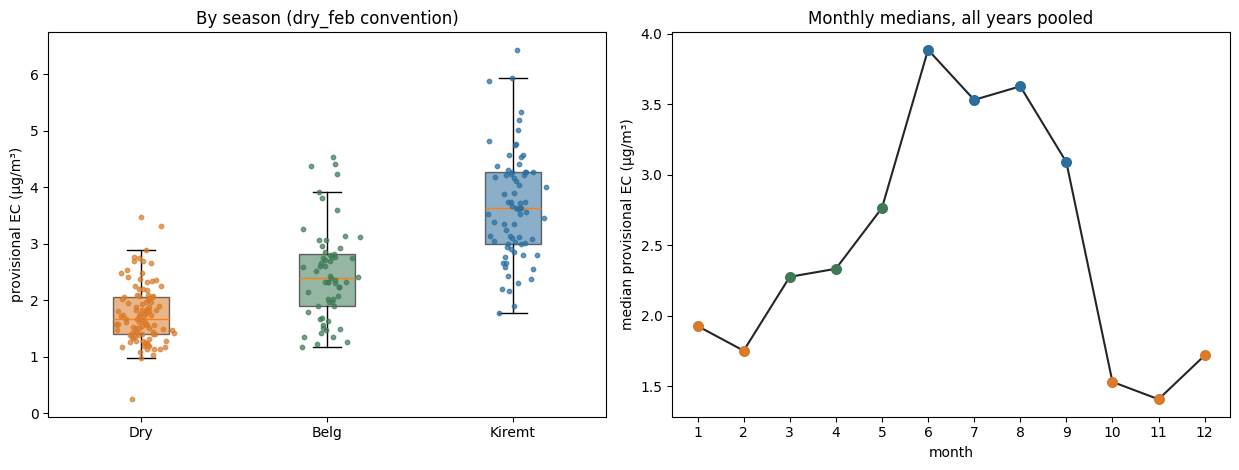

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
ax = axes[0]
data = [series.loc[series['season'].eq(s), 'EC_provisional_ugm3'] for s in SEASON_ORDER]
box = ax.boxplot(data, tick_labels=SEASON_ORDER, patch_artist=True, showfliers=False)
for patch, season in zip(box['boxes'], SEASON_ORDER):
    patch.set(facecolor=SEASON_COLOUR[season], alpha=.55)
for i, (vals, season) in enumerate(zip(data, SEASON_ORDER), start=1):
    ax.scatter(np.random.default_rng(29).normal(i, .06, len(vals)), vals, s=10,
               color=SEASON_COLOUR[season], alpha=.7, zorder=3)
ax.set(ylabel='provisional EC (µg/m³)', title='By season (dry_feb convention)')
ax = axes[1]
monthly = series.groupby(series['SamplingStartDate'].dt.month)['EC_provisional_ugm3'].median()
ax.plot(monthly.index, monthly.values, color=INK, marker='o')
for m, v in monthly.items():
    ax.scatter([m], [v], color=SEASON_COLOUR[SEASON_FOR_MONTH[m]], s=48, zorder=3)
ax.set(xticks=range(1, 13), xlabel='month', ylabel='median provisional EC (µg/m³)',
       title='Monthly medians, all years pooled')
fig.tight_layout()
fig.savefig(PLOT_DIR / 'seasonal_structure.png', dpi=150)
plt.show()

### 7. Figure 4 — the model envelope and the axis disagreement, in one view

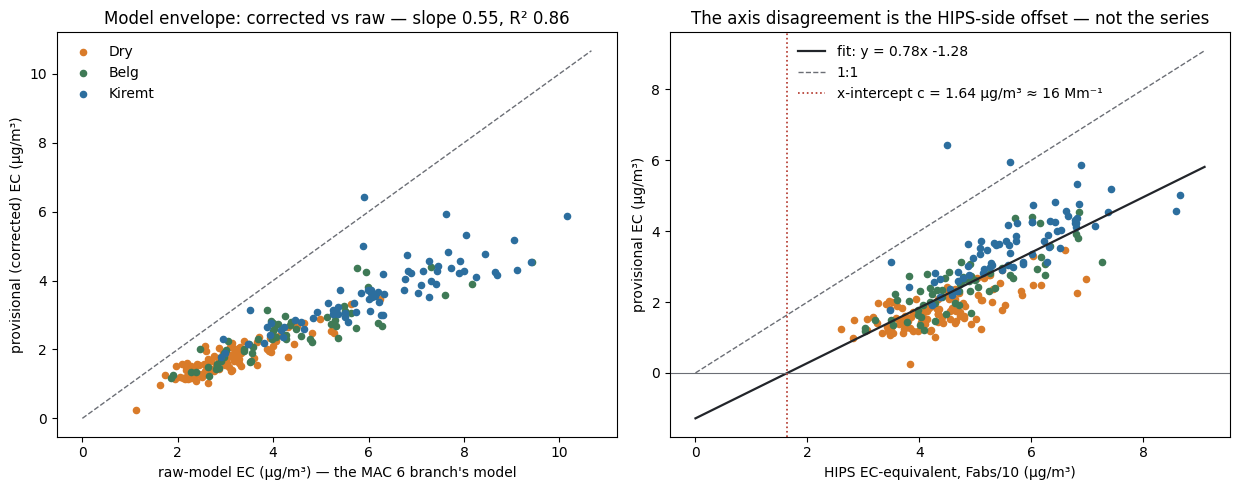

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5))
ax = axes[0]
mm = regression_metrics(series['EC_rawmodel_ugm3'].to_numpy(),
                        series['EC_provisional_ugm3'].to_numpy())
for season in SEASON_ORDER:
    part = series[series['season'].eq(season)]
    ax.scatter(part['EC_rawmodel_ugm3'], part['EC_provisional_ugm3'], s=20,
               color=SEASON_COLOUR[season], label=season)
lim = [0, series['EC_rawmodel_ugm3'].max() * 1.05]
ax.plot(lim, lim, color=MUTED, lw=1, ls='--')
ax.set(xlabel='raw-model EC (µg/m³) — the MAC 6 branch\'s model',
       ylabel='provisional (corrected) EC (µg/m³)',
       title=f'Model envelope: corrected vs raw — slope {mm["slope"]:.2f}, R² {mm["R2"]:.2f}')
ax.legend(frameon=False)
ax = axes[1]
x = series['HIPS_ECeq_MAC10'].to_numpy()
yv = series['EC_provisional_ugm3'].to_numpy()
for season in SEASON_ORDER:
    part = series[series['season'].eq(season)]
    ax.scatter(part['HIPS_ECeq_MAC10'], part['EC_provisional_ugm3'], s=20,
               color=SEASON_COLOUR[season])
mx = regression_metrics(x, yv)
grid = np.linspace(0, np.nanmax(x) * 1.05, 50)
ax.plot(grid, mx['slope'] * grid + mx['intercept'], color=INK, lw=1.6,
        label=f'fit: y = {mx["slope"]:.2f}x {mx["intercept"]:+.2f}')
ax.plot(grid, grid, color=MUTED, lw=1, ls='--', label='1:1')
ax.axhline(0, color=MUTED, lw=.8)
c_here = -mx['intercept'] / mx['slope']
ax.axvline(c_here, color='#B23327', lw=1.2, ls=':',
           label=f'x-intercept c = {c_here:.2f} µg/m³ ≈ {c_here*10:.0f} Mm⁻¹')
ax.set(xlabel='HIPS EC-equivalent, Fabs/10 (µg/m³)', ylabel='provisional EC (µg/m³)',
       title='The axis disagreement is the HIPS-side offset — not the series')
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(PLOT_DIR / 'model_envelope_and_offset.png', dpi=150)
plt.show()

### 8. Figure 5 — the offset `c` with a bootstrap CI, from ftir_15's committed draws

`c = −intercept/slope` per draw; site-cluster draws (B = 200 per model), no refitting.

,model,c_median_ugm3,c_lo95,c_hi95,c_median_Mm-1_MAC10,c_lo95_Mm-1,c_hi95_Mm-1
0,AIRSpec df1=6 (k=5),1.819,1.604,1.970,18.190,16.041,19.697
1,raw (k=6),2.063,1.928,2.237,20.631,19.284,22.371


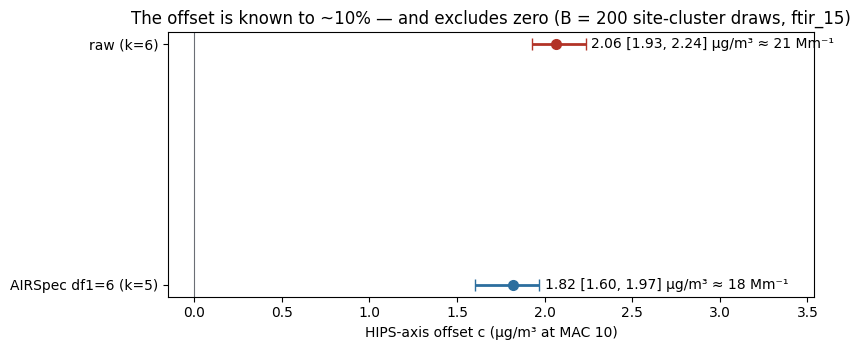

In [9]:
draws = pd.read_csv('output/tables/ftir15/addis_bootstrap_draws.csv')
draws['c'] = -draws['intercept'] / draws['slope']
ci_rows = []
for model, part in draws.groupby('model'):
    lo, med, hi = part['c'].quantile([.025, .5, .975])
    ci_rows.append({'model': model, 'c_median_ugm3': med, 'c_lo95': lo, 'c_hi95': hi,
                    'c_median_Mm-1_MAC10': med * 10, 'c_lo95_Mm-1': lo * 10, 'c_hi95_Mm-1': hi * 10})
ci = pd.DataFrame(ci_rows)
ci.to_csv(TABLE_DIR / 'c_bootstrap_ci.csv', index=False)
display(ci.round(3))

fig, ax = plt.subplots(figsize=(8.5, 3.6))
for i, row in ci.iterrows():
    colour = SEASON_COLOUR['Kiremt'] if 'AIRSpec' in row['model'] else '#B23327'
    ax.errorbar(row['c_median_ugm3'], i, xerr=[[row['c_median_ugm3'] - row['c_lo95']],
                                               [row['c_hi95'] - row['c_median_ugm3']]],
                fmt='o', color=colour, capsize=4, lw=2, markersize=7)
    ax.text(row['c_hi95'] + .03, i, f"{row['c_median_ugm3']:.2f} [{row['c_lo95']:.2f}, "
            f"{row['c_hi95']:.2f}] µg/m³ ≈ {row['c_median_Mm-1_MAC10']:.0f} Mm⁻¹", va='center')
ax.axvline(0, color=MUTED, lw=.8)
ax.set(yticks=range(len(ci)), yticklabels=ci['model'], xlim=(-.15, ci['c_hi95'].max() + 1.3),
       xlabel='HIPS-axis offset c (µg/m³ at MAC 10)',
       title='The offset is known to ~10% — and excludes zero (B = 200 site-cluster draws, ftir_15)')
fig.tight_layout()
fig.savefig(PLOT_DIR / 'c_bootstrap_ci.png', dpi=150)
plt.show()

### 9. Summary table for the record

In [10]:
summary = pd.DataFrame([{
    'series': 'provisional (OCEC-800 + AIRSpec, site-held-out)',
    'n_dated': len(series),
    'median_ugm3': series['EC_provisional_ugm3'].median(),
    'p25': series['EC_provisional_ugm3'].quantile(.25),
    'p75': series['EC_provisional_ugm3'].quantile(.75),
    'max': series['EC_provisional_ugm3'].max(),
    'share_gt8': float((series['EC_provisional_ugm3'] > 8).mean()),
    'share_negative': neg_share,
    'heldout_TOR_slope': fits['AIRSpec df1=6 (k=5)'].heldout['slope'],
    'heldout_TOR_R2': fits['AIRSpec df1=6 (k=5)'].heldout['R2'],
}])
summary.to_csv(TABLE_DIR / 'provisional_summary.csv', index=False)
display(summary.round(3))
print('Done: tables in output/tables/ftir29, figures in output/plots/ftir29')

,series,n_dated,median_ugm3,p25,p75,max,share_gt8,share_negative,heldout_TOR_slope,heldout_TOR_R2
0,"provisional (OCEC-800 + AIRSpec, site-held-out)",239,2.315,1.624,3.123,6.435,0.0,0.0,1.011,0.904


Done: tables in output/tables/ftir29, figures in output/plots/ftir29


## Takeaways

- **"Did the calibration help?" now has a constructive answer.** Beyond closing 61% of the
  intercept, its product is a defensible provisional EC series: shape supported by the
  held-out TOR test (slope 1.01, R² 0.90) and by tracking deployed EC at R² 0.85; zero
  negatives; the expected seasonal ordering. The disagreement it carries is with the HIPS
  axis, which ftir_25–28 localized away from the FTIR side.
- **The absolute scale is the conditional part.** Corrected-branch and raw-branch series
  differ by ≈×1.7 in the median (2.32 vs 3.96 µg/m³) — the unresolved MAC-fork factor —
  and quartz TOR is what collapses it. Quote the series as "provisional, corrected-branch
  headline, raw-branch envelope".
- **If the corrected branch is right, Addis EC is lower than every prior number in this
  project's orbit**: half the deployed SPARTAN values and far below the historical
  15–20 µg/m³ literature range. That is a presentation-sensitive claim — say
  "provisional" every time, and note the deployed comparison is a scale change (0.45×,
  R² 0.85), not a contradiction of the temporal pattern.
- **The offset is now a number with an interval, not a residual**: c excludes zero in both
  models and the two CIs barely overlap ([1.93, 1.97] µg/m³) — ftir_25's −7.3% cross-model
  drift in c sits at the edge of sampling uncertainty.
- **Pre-registered corollary**: at ETBI (median Fabs 26.9 Mm⁻¹), this model should predict
  EC well below Fabs/10 − c would suggest; the day the ETBI spectra arrive, that is the
  out-of-sample test of the whole construction.